# MODULE 4 GROUP 14 — Summative Lab
## DataVine Analytics: Three Machine Learning Projects


Three client projects using classification, recommendation and clustering.

| Project | Dataset | Technique |
|---|---|---|
| A. Wine variety classification | Wine | k-NN + PCA + GridSearchCV |
| B. Chicken feed recommendation | Chickwts | PCA + cosine similarity |
| C. Regional crime pattern analysis | USArrests | K-Means + GMM + PCA |

1.	IMPORT LIBRARIES

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
np.random.seed(42)


2.	DATASET PREPARATION

Load and Inspect the Wine Dataset.


In [ ]:
wine = pd.read_csv("wine.csv")
print("Shape:", wine.shape)
wine.head()


Shape: (178, 14)


,Wine,Alcohol,Malic.acid,Ash,Acl,Mg,Phenols,Flavanoids,Nonflavanoid.phenols,Proanth,Color.int,Hue,OD,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [ ]:
wine.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Wine                  178 non-null    int64  
 1   Alcohol               178 non-null    float64
 2   Malic.acid            178 non-null    float64
 3   Ash                   178 non-null    float64
 4   Acl                   178 non-null    float64
 5   Mg                    178 non-null    int64  
 6   Phenols               178 non-null    float64
 7   Flavanoids            178 non-null    float64
 8   Nonflavanoid.phenols  178 non-null    float64
 9   Proanth               178 non-null    float64
 10  Color.int             178 non-null    float64
 11  Hue                   178 non-null    float64
 12  OD                    178 non-null    float64
 13  Proline               178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB


In [ ]:
print("Summary statistics:")
wine.describe().T


Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Wine,178.0,1.938202,0.775035,1.00,1.0000,2.000,3.0000,3.00
Alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
Malic.acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
Ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
Acl,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
Mg,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
Phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
Flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
Nonflavanoid.phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
Proanth,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58


b)	Check for Missing Values and Duplicates

In [ ]:
print("Missing values per column:")
print(wine.isnull().sum())

print("\nTotal missing values:", wine.isnull().sum().sum())
print("Duplicate rows:", wine.duplicated().sum())


Missing values per column:
Wine                    0
Alcohol                 0
Malic.acid              0
Ash                     0
Acl                     0
Mg                      0
Phenols                 0
Flavanoids              0
Nonflavanoid.phenols    0
Proanth                 0
Color.int               0
Hue                     0
OD                      0
Proline                 0
dtype: int64

Total missing values: 0
Duplicate rows: 0


No missing values or duplicate records were found in the Wine dataset, so no imputation or row dropping is required. The dataset is already numeric

c)	Class Distribution

Class distribution:
Wine
1    59
2    71
3    48
Name: count, dtype: int64


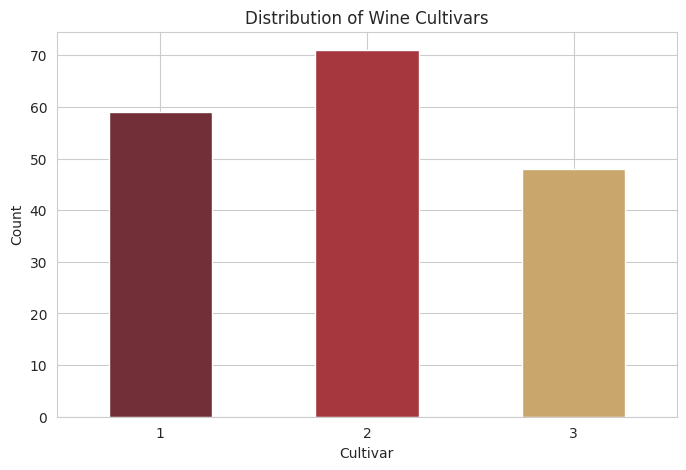

In [ ]:
print("Class distribution:")
print(wine["Wine"].value_counts().sort_index())

wine["Wine"].value_counts().sort_index().plot(kind="bar", color=["#722F37", "#A6373E", "#C9A66B"])
plt.title("Distribution of Wine Cultivars")
plt.xlabel("Cultivar")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


Encode the Target Variable




In [ ]:
le = LabelEncoder()
X = wine.drop(columns=["Wine"])
y_raw = wine["Wine"]
y = le.fit_transform(y_raw)

print("Original classes:", le.classes_)
print("Encoded classes:", np.unique(y))
print("Feature columns:", list(X.columns))


Original classes: [1 2 3]
Encoded classes: [0 1 2]
Feature columns: ['Alcohol', 'Malic.acid', 'Ash', 'Acl', 'Mg', 'Phenols', 'Flavanoids', 'Nonflavanoid.phenols', 'Proanth', 'Color.int', 'Hue', 'OD', 'Proline']


e)	Standardize the Numerical Features like poline by scaling every feature to zero mean and unit variance.


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.describe().T[["mean", "std"]].round(3)


,mean,std
Alcohol,-0.0,1.003
Malic.acid,-0.0,1.003
Ash,-0.0,1.003
Acl,-0.0,1.003
Mg,-0.0,1.003
Phenols,0.0,1.003
Flavanoids,-0.0,1.003
Nonflavanoid.phenols,0.0,1.003
Proanth,-0.0,1.003
Color.int,0.0,1.003


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (133, 13)
Test shape: (45, 13)


b)	Dimensionality Reduction with PCA

We fit PCA on the standardized training features


In [ ]:
pca = PCA(n_components=0.95, random_state=42)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Original number of features: {X_train.shape[1]}")
print(f"Number of components retained: {pca.n_components_}")
print(f"Cumulative variance: {pca.explained_variance_ratio_.sum():.4f}")


Original number of features: 13
Number of components retained: 10
Cumulative variance: 0.9641


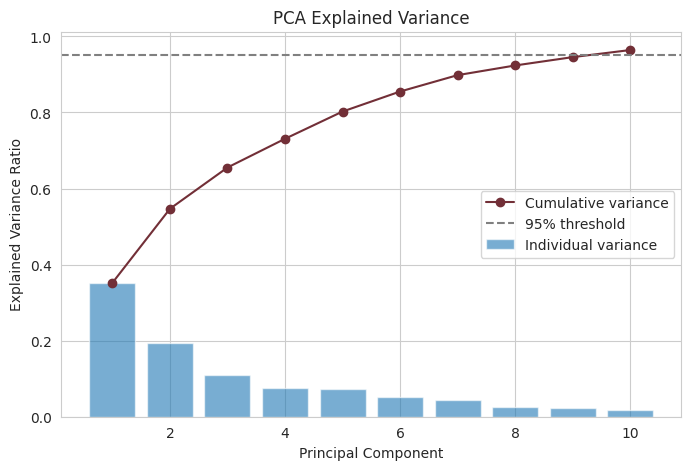

In [ ]:
# Visualize cumulative explained variance
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

fig, ax = plt.subplots()
ax.bar(range(1, len(explained) + 1), explained, alpha=0.6, label="Individual variance")
ax.plot(range(1, len(explained) + 1), cum_explained, marker="o", color="#722F37", label="Cumulative variance")
ax.axhline(0.95, color="gray", linestyle="--", label="95% threshold")
ax.set_xlabel("Principal Component")
ax.set_ylabel("Explained Variance Ratio")
ax.set_title("PCA Explained Variance")
ax.legend()
plt.show()


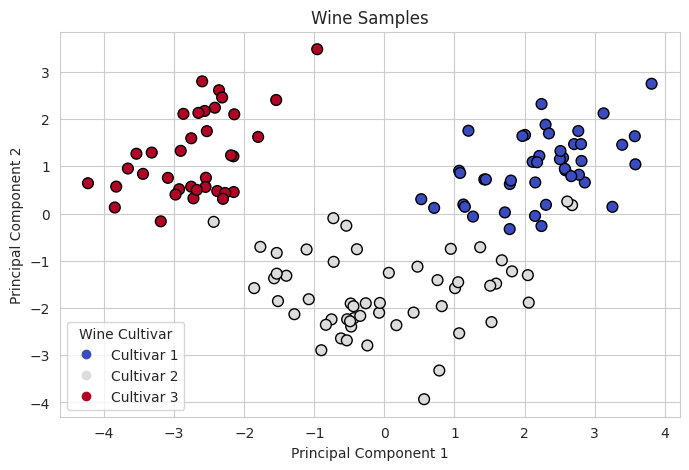

In [ ]:
# Visualize the wines in the first two principal components
fig, ax = plt.subplots()
scatter = ax.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap="coolwarm", edgecolor="k", s=60)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("Wine Samples")
legend_labels = [f"Cultivar {c}" for c in le.classes_]
handles, _ = scatter.legend_elements()
ax.legend(handles, legend_labels, title="Wine Cultivar")
plt.show()


The first two principal components  show separated clusters

c)	Hyperparameter Tuning with GridSearchCV




In [ ]:
param_grid = {
    "n_neighbors": list(range(1, 21)),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
}

knn = KNeighborsClassifier()

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)

grid_search.fit(X_train_pca, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best cross-validated accuracy: {grid_search.best_score_:.4f}")


Best parameters: {'metric': 'manhattan', 'n_neighbors': 14, 'weights': 'distance'}
Best cross-validated accuracy: 0.9772


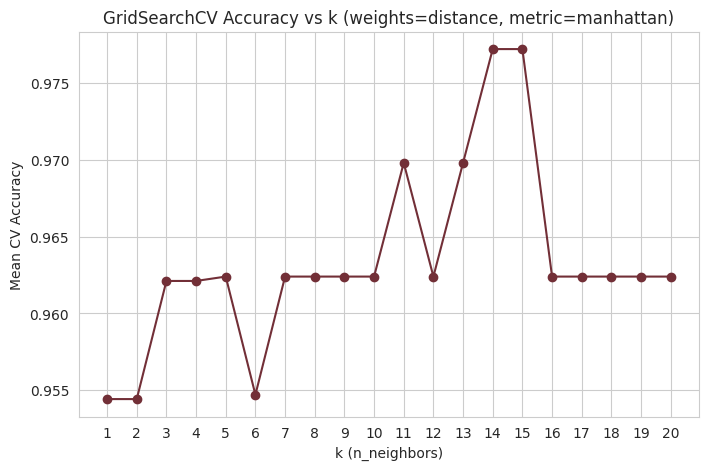

In [ ]:
# Inspect how accuracy varies with k for the best weighting/metric
results = pd.DataFrame(grid_search.cv_results_)
results["param_n_neighbors"] = results["param_n_neighbors"].astype(int)

best_weights = grid_search.best_params_["weights"]
best_metric = grid_search.best_params_["metric"]

subset = results[
    (results["param_weights"] == best_weights) & (results["param_metric"] == best_metric)
].sort_values("param_n_neighbors")

plt.plot(subset["param_n_neighbors"], subset["mean_test_score"], marker="o", color="#722F37")
plt.xlabel("k (n_neighbors)")
plt.ylabel("Mean CV Accuracy")
plt.title(f"GridSearchCV Accuracy vs k (weights={best_weights}, metric={best_metric})")
plt.xticks(subset["param_n_neighbors"])
plt.show()

d)	Train the Final k-NN Classifier with the Best Parameters

In [ ]:
best_knn = grid_search.best_estimator_
best_knn.fit(X_train_pca, y_train)

y_pred = best_knn.predict(X_test_pca)
print("Model trained using best parameters:", grid_search.best_params_)


Model trained using best parameters: {'metric': 'manhattan', 'n_neighbors': 14, 'weights': 'distance'}


4.	Model Evaluation and Interpretation.
  
a)	Accuracy and Classification Report


In [ ]:
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=[f"Cultivar {c}" for c in le.classes_]))


Test Accuracy: 0.9556

Classification Report:
              precision    recall  f1-score   support

  Cultivar 1       0.94      1.00      0.97        15
  Cultivar 2       1.00      0.89      0.94        18
  Cultivar 3       0.92      1.00      0.96        12

    accuracy                           0.96        45
   macro avg       0.95      0.96      0.96        45
weighted avg       0.96      0.96      0.96        45



b)	Confusion Matrix

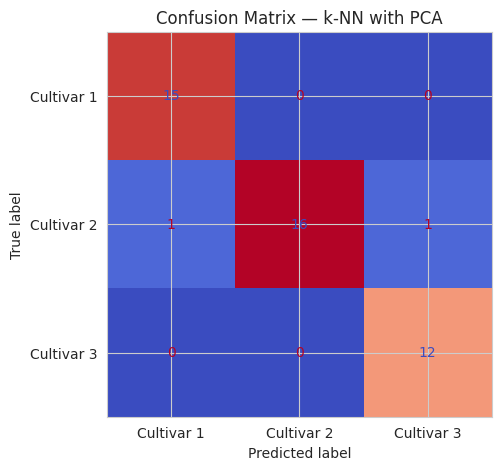

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[f"Cultivar {c}" for c in le.classes_])
disp.plot(ax=ax, cmap="coolwarm", colorbar=False)
ax.set_title("Confusion Matrix — k-NN with PCA")
plt.show()


Decision Boundary Visualization

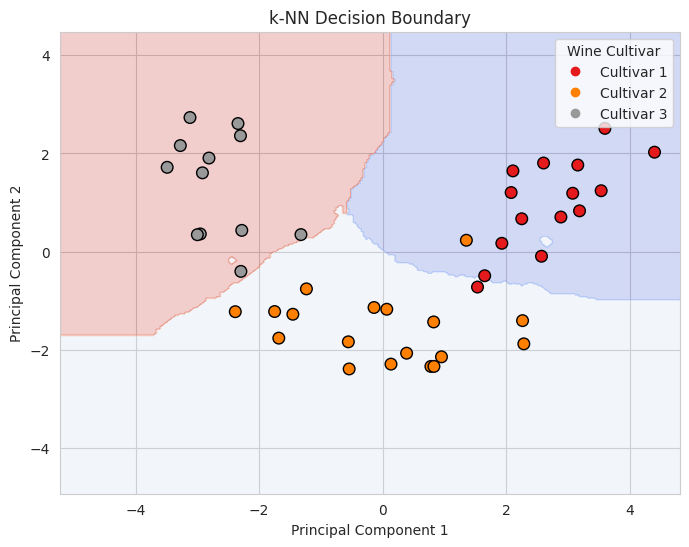

In [ ]:
# Refit a 2D-only model purely for visualization of the decision boundary
knn_2d = KNeighborsClassifier(
    n_neighbors=grid_search.best_params_["n_neighbors"],
    weights=grid_search.best_params_["weights"],
    metric=grid_search.best_params_["metric"],
)
knn_2d.fit(X_train_pca[:, :2], y_train)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
Z = knn_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
ax.contourf(xx, yy, Z, alpha=0.25, cmap="coolwarm")
scatter = ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test, cmap="Set1", edgecolor="k", s=70)
ax.set_xlabel("Principal Component 1")
ax.set_ylabel("Principal Component 2")
ax.set_title("k-NN Decision Boundary")
handles, _ = scatter.legend_elements()
ax.legend(handles, [f"Cultivar {c}" for c in le.classes_], title="Wine Cultivar")
plt.show()


a)	Feature Importance via PCA Loadings

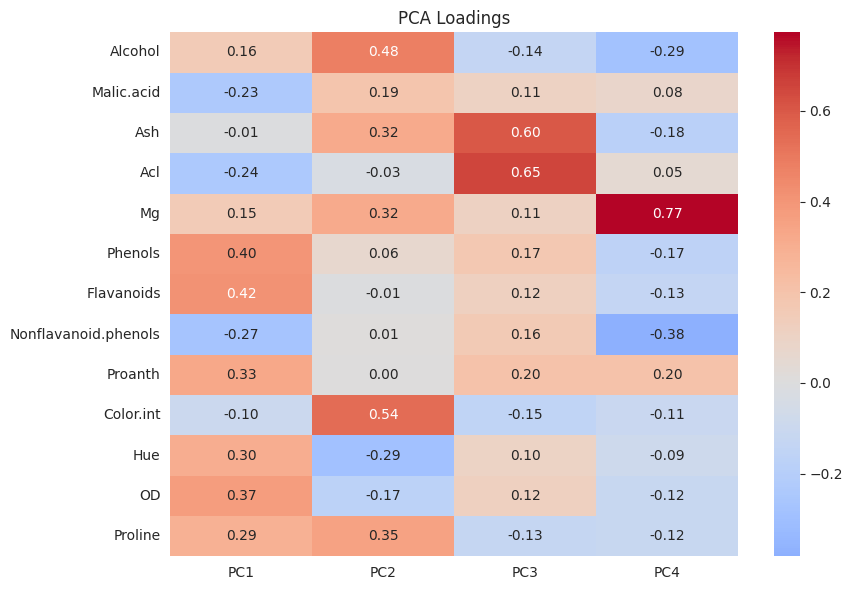

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=X.columns,
)

plt.figure(figsize=(9, 6))
sns.heatmap(loadings.iloc[:, :4], annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("PCA Loadings")
plt.tight_layout()
plt.show()


5.	Summary of Insights for Stakeholders

In [ ]:
print("SUMMARY OF RESULTS")
print(f"Original number of features:      {X.shape[1]}")
print(f"Principal components:  {pca.n_components_}")
print(f"Variance retained by PCA:         {pca.explained_variance_ratio_.sum():.2%}")
print(f"Best GridSearchCV parameters:     {grid_search.best_params_}")
print(f"Best cross-validated accuracy:    {grid_search.best_score_:.2%}")
print(f"Final test accuracy:              {test_accuracy:.2%}")


SUMMARY OF RESULTS
Original number of features:      13
Principal components:  2
Variance retained by PCA:         88.86%
Best GridSearchCV parameters:     {'metric': 'manhattan', 'n_neighbors': 14, 'weights': 'distance'}
Best cross-validated accuracy:    97.72%
Final test accuracy:              95.56%


 The Wine dataset contained no missing values or duplicates so it was ready for modeling after standardization.
  
 PCA reduced the 13 correlated chemical features down to a much smaller set of principal components while retaining 95% of the variance, simplifying the model

 GridSearchCV searched across k values,  to find the optimal k-NN  via  cross-validation.






B. FEEDWISE ANALYTICS CHICKEN FEED RECOMMENDATION SYSTEM



An agricultural supply company wants to recommend similar feed types to farmers based on performance data. Using the chicken weights dataset

 Load and clean the chickwts dataset.

 Summarize the dataset.

Aggregate performance by feed type and standardize the weight feature,Apply PCA to reduce the data to one principal component.

Compute cosine similarity between feed types.

Recommend similar feeds based on similarity scores



1.	IMPORT LIBRARIES

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# (StandardScaler and PCA were already imported in Part 1 above)



Load and Inspect the Chickwts Dataset.


In [ ]:
chick_df = pd.read_csv("chickwts.csv")
if "rownames" in chick_df.columns:
    chick_df = chick_df.drop(columns=["rownames"])

print(f"Shape: {chick_df.shape}")
chick_df.head()


Shape: (71, 2)


,weight,feed
0,179,horsebean
1,160,horsebean
2,136,horsebean
3,227,horsebean
4,217,horsebean


b)	Check for Missing Values and Duplicates

In [ ]:
print("Missing values per column:")
print(chick_df.isnull().sum())
print(f"\nDuplicate rows: {chick_df.duplicated().sum()}")
print(f"\nFeed types: {sorted(chick_df['feed'].unique())}")


Missing values per column:
weight    0
feed      0
dtype: int64

Duplicate rows: 1

Feed types: ['casein', 'horsebean', 'linseed', 'meatmeal', 'soybean', 'sunflower']


No missing values were found in the chickwts dataset, so no imputation required.

Summarize the Dataset

We confirm the dataset's by summarizing the distribution of chick weight for each feed type.

In [ ]:
summary_stats = chick_df.groupby("feed")["weight"].describe()
summary_stats


,count,mean,std,min,25%,50%,75%,max
feed,,,,,,,,
casein,12.0,323.583333,64.433840,216.0,277.25,342.0,370.75,404.0
horsebean,10.0,160.200000,38.625841,108.0,137.00,151.5,176.25,227.0
linseed,12.0,218.750000,52.235698,141.0,178.00,221.0,257.75,309.0
meatmeal,11.0,276.909091,64.900623,153.0,249.50,263.0,320.00,380.0
soybean,14.0,246.428571,54.129068,158.0,206.75,248.0,270.00,329.0
sunflower,12.0,328.916667,48.836384,226.0,312.75,328.0,340.25,423.0


/tmp/ipykernel_4800/512569948.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=chick_df, x="feed", y="weight", order=order, palette="viridis")


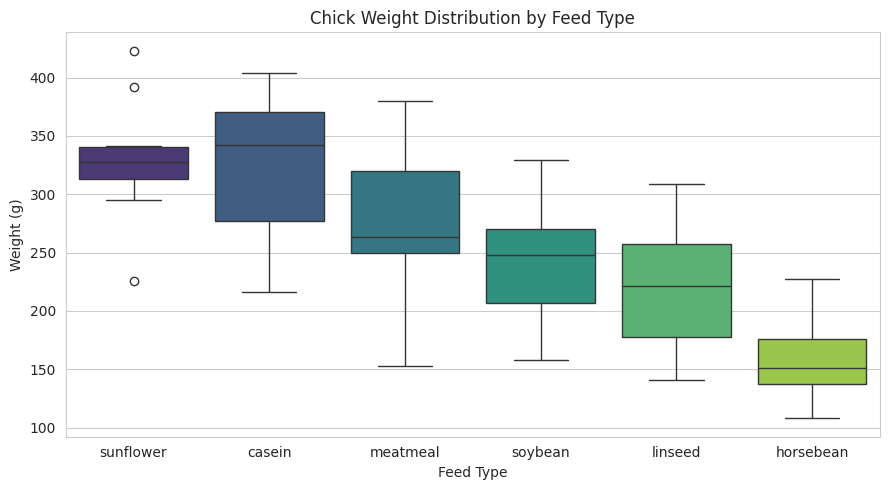

In [ ]:
plt.figure(figsize=(9, 5))
order = chick_df.groupby("feed")["weight"].mean().sort_values(ascending=False).index
sns.boxplot(data=chick_df, x="feed", y="weight", order=order, palette="viridis")
plt.title("Chick Weight Distribution by Feed Type")
plt.xlabel("Feed Type")
plt.ylabel("Weight (g)")
plt.tight_layout()
plt.show()


Feed types ie casein and sunflower are associated with visibly higher chick weights, while horsebean produces the lowest weights.

Building the Recommendation System
Aggregate Performance by Feed Type



In [ ]:
feed_profile = chick_df.groupby("feed")["weight"].agg(
    mean_weight="mean",
    median_weight="median",
    std_weight="std",
    min_weight="min",
    max_weight="max",
).reset_index()

feed_profile


,feed,mean_weight,median_weight,std_weight,min_weight,max_weight
0,casein,323.583333,342.0,64.433840,216,404
1,horsebean,160.200000,151.5,38.625841,108,227
2,linseed,218.750000,221.0,52.235698,141,309
3,meatmeal,276.909091,263.0,64.900623,153,380
4,soybean,246.428571,248.0,54.129068,158,329
5,sunflower,328.916667,328.0,48.836384,226,423


b)	Standardize the Weight Feature

standardize the performance features before comparing feed types.

In [ ]:
feature_cols = ["mean_weight", "median_weight", "std_weight", "min_weight", "max_weight"]

feed_scaler = StandardScaler()
feed_scaled = feed_scaler.fit_transform(feed_profile[feature_cols])

feed_scaled_df = pd.DataFrame(feed_scaled, columns=feature_cols, index=feed_profile["feed"])
feed_scaled_df


,mean_weight,median_weight,std_weight,min_weight,max_weight
feed,,,,,
casein,1.091532,1.292634,1.165613,1.181724,0.886698
horsebean,-1.675457,-1.671219,-1.679411,-1.422892,-1.788510
linseed,-0.683880,-0.589918,-0.179087,-0.627037,-0.549148
meatmeal,0.301077,0.063530,1.217070,-0.337635,0.523958
soybean,-0.215128,-0.169845,0.029635,-0.217051,-0.246865
sunflower,1.181855,1.074818,-0.553820,1.422892,1.173867


Apply PCA to Reduce to One Principal Component



In [ ]:
feed_pca = PCA(n_components=1, random_state=42)
feed_pc1 = feed_pca.fit_transform(feed_scaled)

feed_profile["PC1"] = feed_pc1
print(f"Variance by PC1: {feed_pca.explained_variance_ratio_[0]:.2%}")
feed_profile[["feed", "PC1"]].sort_values("PC1", ascending=False)


Variance by PC1: 86.76%


,feed,PC1
0,casein,2.489486
5,sunflower,2.082970
3,meatmeal,0.687943
4,soybean,-0.388119
2,linseed,-1.211577
1,horsebean,-3.660704


/tmp/ipykernel_4800/2191632596.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=order2, x="feed", y="PC1", palette="viridis")


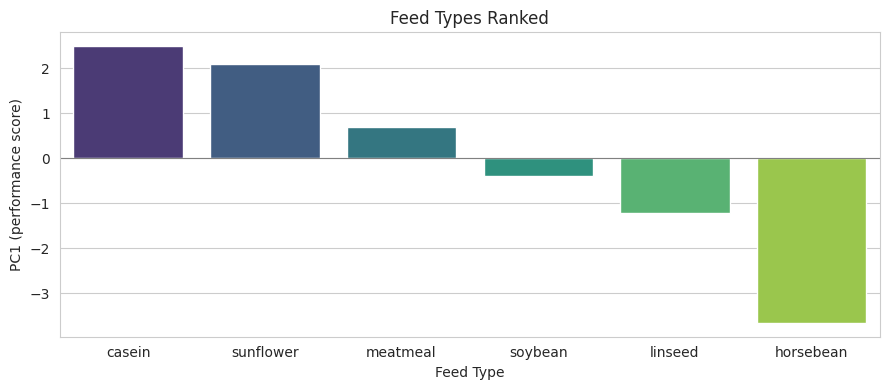

In [ ]:
plt.figure(figsize=(9, 4))
order2 = feed_profile.sort_values("PC1", ascending=False)
sns.barplot(data=order2, x="feed", y="PC1", palette="viridis")
plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Feed Types Ranked")
plt.xlabel("Feed Type")
plt.ylabel("PC1 (performance score)")
plt.tight_layout()
plt.show()


Compute Cosine Similarity Between Feed Types



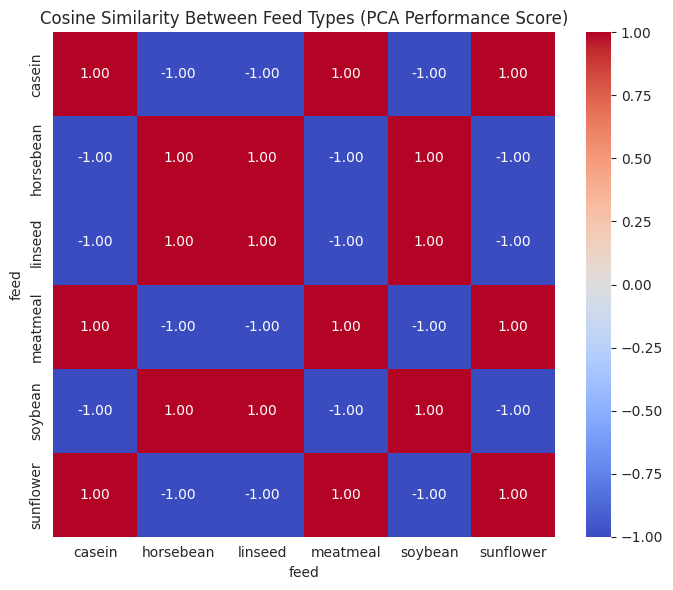

In [ ]:
sim_matrix = cosine_similarity(feed_pc1)
similarity_df = pd.DataFrame(sim_matrix, index=feed_profile["feed"], columns=feed_profile["feed"])

plt.figure(figsize=(7, 6))
sns.heatmap(similarity_df, annot=True, cmap="coolwarm", center=0, fmt=".2f", vmin=-1, vmax=1)
plt.title("Cosine Similarity Between Feed Types (PCA Performance Score)")
plt.tight_layout()
plt.show()


4.	Generating Recommendations

a)	Recommend Similar Feeds

Given a feed a farmer is currently using, we recommend the most similar alternative feed types, ranked by cosine similarity score.

In [ ]:
def recommend_similar_feeds(feed_name, top_n=3):
    if feed_name not in similarity_df.index:
        raise ValueError(f"Unknown feed: {feed_name}")
    scores = similarity_df.loc[feed_name].drop(index=feed_name)
    scores = scores.sort_values(ascending=False).head(top_n)
    return scores.rename("cosine_similarity").reset_index().rename(columns={"index": "feed"})


for query_feed in ["horsebean", "casein", "soybean"]:
    print(f"Feeds most similar to '{query_feed}':")
    print(recommend_similar_feeds(query_feed, top_n=3).to_string(index=False))


Feeds most similar to 'horsebean':
   feed  cosine_similarity
linseed                1.0
soybean                1.0
 casein               -1.0
Feeds most similar to 'casein':
     feed  cosine_similarity
 meatmeal                1.0
sunflower                1.0
horsebean               -1.0
Feeds most similar to 'soybean':
     feed  cosine_similarity
horsebean                1.0
  linseed                1.0
   casein               -1.0


5.	Summary of Insights for Stakeholders

In [ ]:
print("CHICKWTS RECOMMENDATION SYSTEM SUMMARY")
print(f"Number of chick observations:      {chick_df.shape[0]}")
print(f"Number of feed types :      {feed_profile.shape[0]}")
print(f"Performance features per feed:     {len(feature_cols)}")
print(f"Variance retained by PC1:          {feed_pca.explained_variance_ratio_[0]:.2%}")
best_feed = feed_profile.sort_values('PC1', ascending=False).iloc[0]['feed']
worst_feed = feed_profile.sort_values('PC1', ascending=True).iloc[0]['feed']
print(f"Highest performing feed :  {best_feed}")
print(f"Lowest performing feed :   {worst_feed}")


CHICKWTS RECOMMENDATION SYSTEM SUMMARY
Number of chick observations:      71
Number of feed types :      6
Performance features per feed:     5
Variance retained by PC1:          86.76%
Highest performing feed :  casein
Lowest performing feed :   horsebean


 The chickwts dataset contained no missing values or duplicates.

 Reducing five correlated performance statistics to a single PCA score.

Cosine similarity on the PCA scores.
 High performing feeds such as casein and sunflower cluster together while horsebean stands apart as a low performing.

 The supply company can use this similarity engine to recommend alternative feed products to farmers.



 US CRIME PATTERN CLUSTERING

**K-Means and Gaussian Mixture Model clustering with feature selection and PCA**

A public policy research firm wants to identify patterns in crime statistics across US states, so resources can be allocated by group rather than state by state.

## 1. Dataset Preparation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from datetime import datetime

In [ ]:
df=pd.read_csv('USArrests.csv')
df.head()

,Murder,Assault,UrbanPop,Rape,State
0,13.2,236,58,21.2,Alabama
1,10.0,263,48,44.5,Alaska
2,8.1,294,80,31.0,Arizona
3,8.8,190,50,19.5,Arkansas
4,9.0,276,91,40.6,California


In [ ]:
df = df.set_index('State')


Set `State` as the index so cluster labels stay tied to state names.

In [ ]:
print(df.dtypes)

Murder      float64
Assault       int64
UrbanPop      int64
Rape        float64
dtype: object


In [ ]:
missing_values = df.isnull().sum()
missing_values


,0
Murder,0
Assault,0
UrbanPop,0
Rape,0


In [ ]:
df.shape

(50, 4)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 50 entries, Alabama to Wyoming
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Murder    50 non-null     float64
 1   Assault   50 non-null     int64  
 2   UrbanPop  50 non-null     int64  
 3   Rape      50 non-null     float64
dtypes: float64(2), int64(2)
memory usage: 2.0+ KB


50 states, 4 numeric features, no missing values — no imputation needed.

In [ ]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

Standardized because K-Means, GMM and PCA are all distance/variance based — Assault (45–337) would otherwise dominate Murder (0.8–17.4).

## 2. Feature Selection

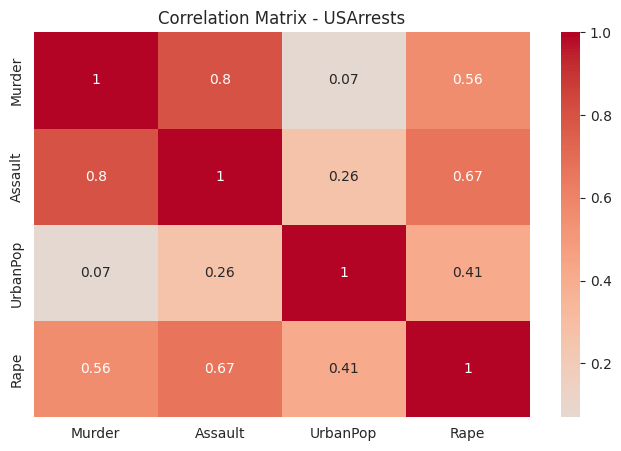

In [ ]:
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix - USArrests')
plt.show()

Murder, Assault and Rape are strongly correlated UrbanPop is nearly independent. We drop it and keep Murder, UrbanPop, Rape , rather than three overlapping measures of the same thing.

In [ ]:
features=['Murder','UrbanPop','Rape']

In [ ]:
df_selected = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_selected)
print(X_scaled.shape)

(50, 3)


## 3. Dimensionality Reduction with PCA

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(pca.explained_variance_ratio_, pca.explained_variance_ratio_.sum())

[0.57731281 0.31126728] 0.8885800845534098


Two components retain **88.9%** of the variance

In [ ]:
pd.DataFrame(pca.components_, columns=features, index=['PC1', 'PC2'])

,Murder,UrbanPop,Rape
PC1,0.573210,0.442179,0.689861
PC2,-0.586889,0.809076,-0.030943


## 4. Determining the Optimal Number of Clusters

### a) Elbow Method for K-Means

In [ ]:
# WCSS for k-means
wcss = []
k_values = range(1,10)

# for loop
for k in k_values:
    kmean=KMeans(n_clusters=k,random_state=42,n_init=10)
    kmean.fit(X_pca)
# WCSS returned
    wcss.append(kmean.inertia_)
round(np.mean(wcss),2)

np.float64(42.07)

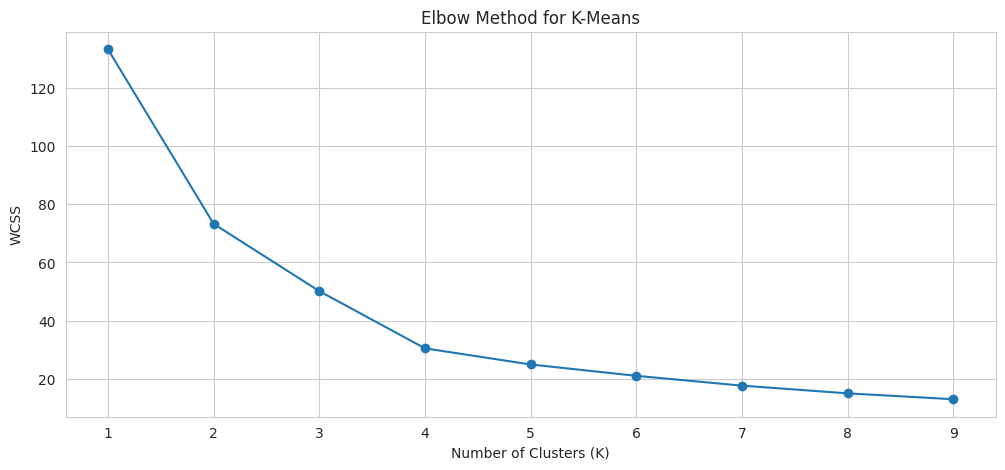

In [ ]:
fig,axes=plt.subplots(figsize=(12,5))
axes.plot(k_values,wcss,marker='o',linestyle='-')
axes.set_xlabel("Number of Clusters (K)")
axes.set_ylabel("WCSS")
axes.set_title("Elbow Method for K-Means")

plt.show()

The curve bends sharply at k = 3

### b) BIC for GMM

In [ ]:
bic_scores = []

# for loop
for n in range(1,10):
    gmm=GaussianMixture(n_components=n,random_state=42,n_init=10)
    gmm.fit(X_pca)
    bic_scores.append(gmm.bic(X_pca))


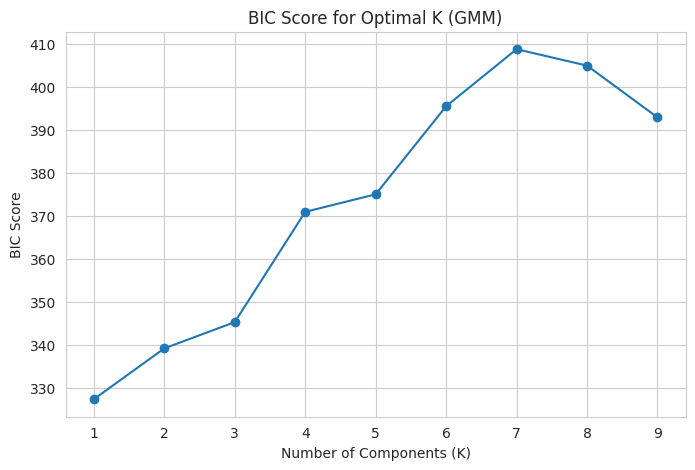

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(k_values, bic_scores, marker='o', linestyle='-')
plt.xlabel("Number of Components (K)")
plt.ylabel("BIC Score")
plt.title("BIC Score for Optimal K (GMM)")
plt.show()

## 5. Applying the Clustering Models

In [ ]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_pca)

gmm = GaussianMixture(n_components=optimal_k, random_state=42, n_init=10)
gmm_labels = gmm.fit_predict(X_pca)
gmm_probs = gmm.predict_proba(X_pca).max(axis=1)

In [ ]:
df['KMeans_Cluster'] = kmeans_labels
df['GMM_Cluster'] = gmm_labels
df['GMM_Probability'] = gmm_probs

K-Means gives hard assignments; GMM adds a per-state confidence score.

## 6. Model Evaluation and Interpretation

In [ ]:
print(df.shape)
print(df.dtypes)
print(df.isna().sum())
df.describe()

(50, 7)
Murder             float64
Assault              int64
UrbanPop             int64
Rape               float64
KMeans_Cluster       int32
GMM_Cluster          int64
GMM_Probability    float64
dtype: object
Murder             0
Assault            0
UrbanPop           0
Rape               0
KMeans_Cluster     0
GMM_Cluster        0
GMM_Probability    0
dtype: int64


,Murder,Assault,UrbanPop,Rape,KMeans_Cluster,GMM_Cluster,GMM_Probability
count,50.00000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,7.78800,170.760000,65.540000,21.232000,1.100000,1.260000,0.952862
std,4.35551,83.337661,14.474763,9.366385,0.788954,0.899206,0.097660
min,0.80000,45.000000,32.000000,7.300000,0.000000,0.000000,0.496529
25%,4.07500,109.000000,54.500000,15.075000,0.250000,0.000000,0.957021
50%,7.25000,159.000000,66.000000,20.100000,1.000000,2.000000,0.996973
75%,11.25000,249.000000,77.750000,26.175000,2.000000,2.000000,0.999984
max,17.40000,337.000000,91.000000,46.000000,2.000000,2.000000,1.000000


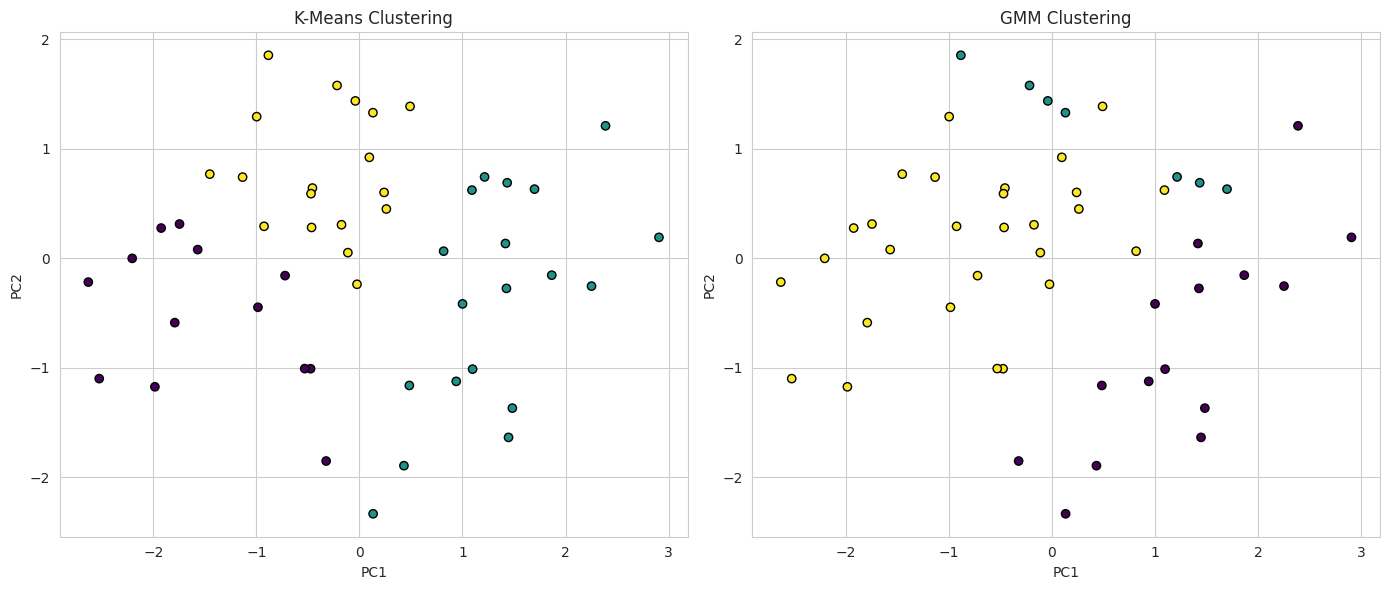

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['KMeans_Cluster'],
                cmap='viridis', marker='o', edgecolor='k')
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2")
axes[0].set_title("K-Means Clustering")

axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df['GMM_Cluster'],
                cmap='viridis', marker='o', edgecolor='k')
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
axes[1].set_title("GMM Clustering")

plt.tight_layout()
plt.show()

Both methods find similar structure along PC1, the overall crime axis.

In [ ]:
# Cluster quality
print(f"K-Means silhouette: {silhouette_score(X_pca, kmeans_labels):.3f}")
print(f"GMM silhouette:     {silhouette_score(X_pca, gmm_labels):.3f}")
print(f"Mean GMM confidence: {df['GMM_Probability'].mean():.3f}")

K-Means silhouette: 0.365
GMM silhouette:     0.227
Mean GMM confidence: 0.953


In [ ]:
# Cluster profiles in original units
df.groupby('KMeans_Cluster')[['Murder','Assault','UrbanPop','Rape']].mean().round(1)

,Murder,Assault,UrbanPop,Rape
KMeans_Cluster,,,,
0,5.1,114.0,49.1,12.9
1,12.1,250.9,69.6,29.9
2,5.2,127.1,73.1,18.2


In [ ]:
# States in each cluster
for c in sorted(df['KMeans_Cluster'].unique()):
    states = df[df['KMeans_Cluster'] == c].index.tolist()
    print(f"\nCluster {c} ({len(states)} states):")
    print(' ', ', '.join(states))


Cluster 0 (13 states):
  Arkansas, Idaho, Iowa, Kentucky, Maine, Montana, New Hampshire, North Carolina, North Dakota, South Dakota, Vermont, West Virginia, Wyoming

Cluster 1 (19 states):
  Alabama, Alaska, Arizona, California, Colorado, Florida, Georgia, Illinois, Louisiana, Maryland, Michigan, Mississippi, Missouri, Nevada, New Mexico, New York, South Carolina, Tennessee, Texas

Cluster 2 (18 states):
  Connecticut, Delaware, Hawaii, Indiana, Kansas, Massachusetts, Minnesota, Nebraska, New Jersey, Ohio, Oklahoma, Oregon, Pennsylvania, Rhode Island, Utah, Virginia, Washington, Wisconsin


In [ ]:
# How much do the two methods agree?
pd.crosstab(df['KMeans_Cluster'], df['GMM_Cluster'])

GMM_Cluster,0,1,2
KMeans_Cluster,,,
0,1,0,12
1,14,3,2
2,0,4,14


Summary

 no missing values or duplicates.



Dimensionality reduction. PCA compressed 3 features to 2 components retaining 88.9% of variance.

Limitation.Any live deployment needs current crime statistics.